# importing Libraries

In [103]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np

In [104]:
df=pd.read_csv('yt_sundas_khalid_metrics.csv')
df.head()

,id,title,description,publishedAt,tags,categoryId,defaultLanguage,defaultAudioLanguage,thumbnails,duration,viewCount,likeCount,commentCount,privacyStatus
0,r4loBN9ffls,Data Analyst Jobs are COOKED 🤯 This is how you...,Is the data analyst job market too saturated? ...,2025-09-22T14:22:16Z,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/r4...,PT1M17S,6140,339.0,5,public
1,NVpxN1vAbNM,H1B is $100K now: How will Big Tech Survive 🤯,NaN,2025-09-20T15:16:16Z,[],28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/NV...,PT1M34S,7736,195.0,52,public
2,yg_K45YtzSs,Data Engineer vs Data Scientist,Here's the difference in less than 60 secs. \n...,2025-09-18T14:22:57Z,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/yg...,PT57S,2103,123.0,1,public
3,xoptBxQvIT0,Why She Quit $200K Software Engineer Job,Get the free Content Creator Tool Kit by HubSp...,2025-09-18T14:15:09Z,"['data science', 'data scientist', 'self-taugh...",28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/xo...,PT22M21S,2231,65.0,3,public
4,w9k1oXwiOJY,5 Data Analyst Projects You NEED,How to stand out in the Data Analyst Job Marke...,2025-09-15T14:22:30Z,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/w9...,PT58S,10992,617.0,4,public


In [105]:
df.shape


(284, 14)

In [106]:
df.columns.tolist()

['id',
 'title',
 'description',
 'publishedAt',
 'tags',
 'categoryId',
 'defaultLanguage',
 'defaultAudioLanguage',
 'thumbnails',
 'duration',
 'viewCount',
 'likeCount',
 'commentCount',
 'privacyStatus']

In [107]:
missing = df.isna().sum().sort_values(ascending=False)
missing

description             86
likeCount                8
id                       0
title                    0
publishedAt              0
tags                     0
categoryId               0
defaultLanguage          0
defaultAudioLanguage     0
thumbnails               0
duration                 0
viewCount                0
commentCount             0
privacyStatus            0
dtype: int64

In [108]:
df['description'] = df['description'].fillna("").replace(r'^\s*$', "No description", regex=True)
df['description'].isna().sum()

0

In [109]:
df['likeCount'] = pd.to_numeric(df['likeCount'], errors='coerce')
avg_like = df['likeCount'].mean()
df['likeCount'] = df['likeCount'].fillna(avg_like).astype(int)
df['likeCount'].isna().sum()

0

In [110]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'], errors='coerce', utc=True)
df['publishedDate'] = df['publishedAt'].dt.date
print(df['publishedAt'].dtype)

datetime64[ns, UTC]


In [111]:
import ast
df['tags'] = df['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip() not in ["", "[]"] else [])
df['tags'].dtype

dtype('O')

In [112]:
df['thumbnails'] = df['thumbnails'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['thumbnails'].dtype

dtype('O')

In [113]:
df['categoryId']=pd.to_numeric(df['categoryId'], errors='coerce')
df['categoryId'].dtype

dtype('int64')

In [121]:
def parse_duration_to_seconds(s):
    if pd.isna(s): 
        return np.nan
    if not isinstance(s, str):
        return np.nan
    
    
    m = re.match(
        r'PT(?:(?P<hours>\d+)H)?(?:(?P<minutes>\d+)M)?(?:(?P<seconds>\d+)S)?', 
        s
    )
    if not m:
        return np.nan
    
    h = int(m.group('hours') or 0)
    m_ = int(m.group('minutes') or 0)
    s_ = int(m.group('seconds') or 0)
    return h*3600 + m_*60 + s_


df['duration_s'] = df['duration'].apply(parse_duration_to_seconds)


In [115]:
df

,id,title,description,publishedAt,tags,categoryId,defaultLanguage,defaultAudioLanguage,thumbnails,duration,viewCount,likeCount,commentCount,privacyStatus,publishedDate,duration_s
0,r4loBN9ffls,Data Analyst Jobs are COOKED 🤯 This is how you...,Is the data analyst job market too saturated? ...,2025-09-22 14:22:16+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/r4...,PT1M17S,6140,339,5,public,2025-09-22,77
1,NVpxN1vAbNM,H1B is $100K now: How will Big Tech Survive 🤯,No description,2025-09-20 15:16:16+00:00,[],28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/NV...,PT1M34S,7736,195,52,public,2025-09-20,94
2,yg_K45YtzSs,Data Engineer vs Data Scientist,Here's the difference in less than 60 secs. \n...,2025-09-18 14:22:57+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/yg...,PT57S,2103,123,1,public,2025-09-18,57
3,xoptBxQvIT0,Why She Quit $200K Software Engineer Job,Get the free Content Creator Tool Kit by HubSp...,2025-09-18 14:15:09+00:00,"[data science, data scientist, self-taugh data...",28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/xo...,PT22M21S,2231,65,3,public,2025-09-18,1341
4,w9k1oXwiOJY,5 Data Analyst Projects You NEED,How to stand out in the Data Analyst Job Marke...,2025-09-15 14:22:30+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/w9...,PT58S,10992,617,4,public,2025-09-15,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Tx8BxhKDCb8,Job families in data science,No description,2020-12-15 19:42:38+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Tx...,PT11S,39253,993,8,public,2020-12-15,11
280,dz9ufVkTq5w,Highly recommend reading ‘The Simple Path to W...,Highly recommend reading ‘The Simple Path to W...,2020-10-28 01:35:46+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/dz...,PT16S,9035,183,6,public,2020-10-28,16
281,K0yr0ZQ1_js,How I Got into FAANG (Data Science),Hello friends!\n\nToday I’m talking about tips...,2020-09-27 16:00:10+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/K0...,PT22M8S,16859,543,60,public,2020-09-27,1328
282,Jwc2SPl7v3Y,Want to be a Data Scientist? This is the First...,"In this video, I talk about the first thing yo...",2020-09-08 15:00:11+00:00,"[data science, women in tech, data scientist, ...",28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Jw...,PT4M11S,28493,1173,52,public,2020-09-08,251


In [116]:
df['viewCount']=pd.to_numeric(df['viewCount'], errors='coerce')
df['viewCount'].dtype

dtype('int64')

In [117]:
df['likeCount'].dtype

dtype('int32')

In [128]:
df['duration']=df['duration_s']
df = df.drop(columns=['duration_s'])

KeyError: 'duration_s'

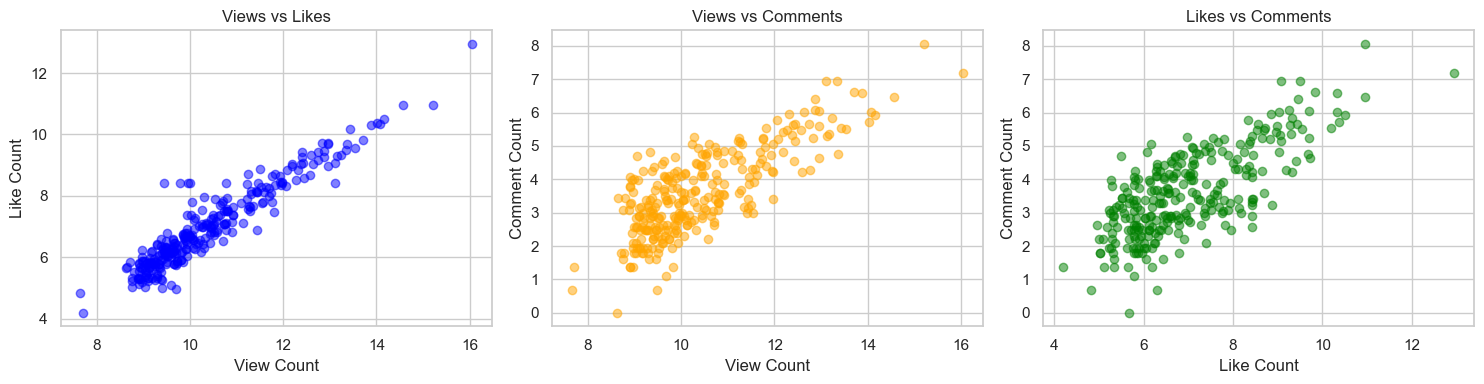

In [119]:

plt.figure(figsize=(15,4))

# 1️⃣ View Count vs Like Count
plt.subplot(1,3,1)
plt.scatter(np.log1p(df['viewCount']), np.log1p(df['likeCount']), alpha=0.5, color='blue')
plt.xlabel('View Count')
plt.ylabel('Like Count')
plt.title('Views vs Likes')

# 2️⃣ View Count vs Comment Count
plt.subplot(1,3,2)
plt.scatter(np.log1p(df['viewCount']), np.log1p(df['commentCount']), alpha=0.5, color='orange')
plt.xlabel('View Count')
plt.ylabel('Comment Count')
plt.title('Views vs Comments')

# 3️⃣ Like Count vs Comment Count
plt.subplot(1,3,3)
plt.scatter(np.log1p(df['likeCount']), np.log1p(df['commentCount']), alpha=0.5, color='green')
plt.xlabel('Like Count')
plt.ylabel('Comment Count')
plt.title('Likes vs Comments')

plt.tight_layout()
plt.show()



In [126]:
df

,id,title,description,publishedAt,tags,categoryId,defaultLanguage,defaultAudioLanguage,thumbnails,duration,viewCount,likeCount,commentCount,privacyStatus,publishedDate
0,r4loBN9ffls,Data Analyst Jobs are COOKED 🤯 This is how you...,Is the data analyst job market too saturated? ...,2025-09-22 14:22:16+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/r4...,77,6140,339,5,public,2025-09-22
1,NVpxN1vAbNM,H1B is $100K now: How will Big Tech Survive 🤯,No description,2025-09-20 15:16:16+00:00,[],28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/NV...,94,7736,195,52,public,2025-09-20
2,yg_K45YtzSs,Data Engineer vs Data Scientist,Here's the difference in less than 60 secs. \n...,2025-09-18 14:22:57+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/yg...,57,2103,123,1,public,2025-09-18
3,xoptBxQvIT0,Why She Quit $200K Software Engineer Job,Get the free Content Creator Tool Kit by HubSp...,2025-09-18 14:15:09+00:00,"[data science, data scientist, self-taugh data...",28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/xo...,1341,2231,65,3,public,2025-09-18
4,w9k1oXwiOJY,5 Data Analyst Projects You NEED,How to stand out in the Data Analyst Job Marke...,2025-09-15 14:22:30+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/w9...,58,10992,617,4,public,2025-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Tx8BxhKDCb8,Job families in data science,No description,2020-12-15 19:42:38+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Tx...,11,39253,993,8,public,2020-12-15
280,dz9ufVkTq5w,Highly recommend reading ‘The Simple Path to W...,Highly recommend reading ‘The Simple Path to W...,2020-10-28 01:35:46+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/dz...,16,9035,183,6,public,2020-10-28
281,K0yr0ZQ1_js,How I Got into FAANG (Data Science),Hello friends!\n\nToday I’m talking about tips...,2020-09-27 16:00:10+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/K0...,1328,16859,543,60,public,2020-09-27
282,Jwc2SPl7v3Y,Want to be a Data Scientist? This is the First...,"In this video, I talk about the first thing yo...",2020-09-08 15:00:11+00:00,"[data science, women in tech, data scientist, ...",28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Jw...,251,28493,1173,52,public,2020-09-08


In [135]:
df.to_csv('Task1_clean',index=False)

In [129]:
task2=pd.read_csv('youtube_transcripts3_kaggle.csv')

In [132]:
df2=task2[['Video ID','Transcript']]

In [133]:
df2.to_csv('Task2_Dataset_50')

In [134]:
df2.to_csv('Task2_Dataset_50.csv', index=False)

In [136]:
df

,id,title,description,publishedAt,tags,categoryId,defaultLanguage,defaultAudioLanguage,thumbnails,duration,viewCount,likeCount,commentCount,privacyStatus,publishedDate
0,r4loBN9ffls,Data Analyst Jobs are COOKED 🤯 This is how you...,Is the data analyst job market too saturated? ...,2025-09-22 14:22:16+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/r4...,77,6140,339,5,public,2025-09-22
1,NVpxN1vAbNM,H1B is $100K now: How will Big Tech Survive 🤯,No description,2025-09-20 15:16:16+00:00,[],28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/NV...,94,7736,195,52,public,2025-09-20
2,yg_K45YtzSs,Data Engineer vs Data Scientist,Here's the difference in less than 60 secs. \n...,2025-09-18 14:22:57+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/yg...,57,2103,123,1,public,2025-09-18
3,xoptBxQvIT0,Why She Quit $200K Software Engineer Job,Get the free Content Creator Tool Kit by HubSp...,2025-09-18 14:15:09+00:00,"[data science, data scientist, self-taugh data...",28,en-US,en,{'default': {'url': 'https://i.ytimg.com/vi/xo...,1341,2231,65,3,public,2025-09-18
4,w9k1oXwiOJY,5 Data Analyst Projects You NEED,How to stand out in the Data Analyst Job Marke...,2025-09-15 14:22:30+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/w9...,58,10992,617,4,public,2025-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,Tx8BxhKDCb8,Job families in data science,No description,2020-12-15 19:42:38+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Tx...,11,39253,993,8,public,2020-12-15
280,dz9ufVkTq5w,Highly recommend reading ‘The Simple Path to W...,Highly recommend reading ‘The Simple Path to W...,2020-10-28 01:35:46+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/dz...,16,9035,183,6,public,2020-10-28
281,K0yr0ZQ1_js,How I Got into FAANG (Data Science),Hello friends!\n\nToday I’m talking about tips...,2020-09-27 16:00:10+00:00,[],28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/K0...,1328,16859,543,60,public,2020-09-27
282,Jwc2SPl7v3Y,Want to be a Data Scientist? This is the First...,"In this video, I talk about the first thing yo...",2020-09-08 15:00:11+00:00,"[data science, women in tech, data scientist, ...",28,en,en,{'default': {'url': 'https://i.ytimg.com/vi/Jw...,251,28493,1173,52,public,2020-09-08
